# YZM0206 Proje - Model Karşılaştırma ve Final Analiz

Bu notebookta önceki deneylerde elde edilen model sonuçları tek bir yerde karşılaştırılmıştır. Amaç yalnızca en yüksek accuracy değerini bulmak değildir. Modellerin genel başarıları, sınıf bazlı davranışları, fine-tuning katkısı, eğitim süresi ve parametre sayıları birlikte değerlendirilmiştir.

Bu analizde karşılaştırılan modeller:

1. Baseline CNN
2. Baseline CNN B
3. MobileNetV2
4. DenseNet121
5. InceptionV3

## TL;DR

Elde edilen sonuçlara göre en yüksek genel performansı **DenseNet121** modeli vermiştir. DenseNet121 test kümesinde **0.9662 accuracy**, **0.9650 macro F1-score** ve **0.1065 test loss** değerine ulaşmıştır. Bu değerler hem baseline CNN modellerinden hem de diğer transfer learning modellerinden daha güçlüdür.

Transfer learning modelleri baseline CNN'e göre belirgin iyileşme sağlamıştır. Baseline CNN test accuracy değeri **0.8207** iken MobileNetV2 **0.9578**, DenseNet121 **0.9662**, InceptionV3 ise **0.9610** test accuracy değerine ulaşmıştır.

Sonuç olarak bu projede en iyi final model adayı DenseNet121 olarak değerlendirilmiştir. Ancak daha düşük model boyutu ve daha kısa eğitim süresi istenirse MobileNetV2 de güçlü bir alternatif olarak görülebilir.

## 1. Analiz Kapsamı ve Kaynak Dosyalar

Bu notebook yeni bir eğitim yapmaz. Daha önceki notebooklarda kaydedilen sonuç dosyalarını okur ve karşılaştırır. Böylece analiz, çalıştırılmış deneylerden gelen sayısal çıktılara dayanır.

Kullanılan temel kaynaklar:

1. `reports/*_metrics.json`: genel model metrikleri
2. `reports/*_classification_report.csv`: sınıf bazlı precision, recall ve F1-score değerleri
3. `reports/*_history.csv`: eğitim ve validation geçmişi
4. `figures/*`: önceki notebooklarda üretilen grafikler

Tüm modeller aynı train / validation / test ayrımı üzerinde değerlendirilmiştir. Bu nedenle model karşılaştırması aynı veri koşulları altında yapılmaktadır.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)


def find_project_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for candidate in candidates:
        if (candidate / "notebooks").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError("Proje klasörü bulunamadı. Notebook proje klasörü içinden çalıştırılmalıdır.")


def annotate_bars(ax, values, fmt="{:.3f}", suffix=""):
    for patch, value in zip(ax.patches, values):
        height = patch.get_height()
        ax.annotate(
            fmt.format(value) + suffix,
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points",
        )


PROJECT_DIR = find_project_dir()
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

for directory in [REPORTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Proje dizini:", PROJECT_DIR)
print("Reports dizini:", REPORTS_DIR)

Proje dizini: C:\Users\Barış\OneDrive\Masaüstü\YZM0206 Proje
Reports dizini: C:\Users\Barış\OneDrive\Masaüstü\YZM0206 Proje\reports


## 2. Deney Tasarımı ve Parametre Özeti

Bu bölümde modellerin hangi ayarlarla eğitildiği özetlenmiştir. Parametrelerin aynı tabloda verilmesi önemlidir; çünkü sonuçlar yalnızca model mimarisine değil, eğitim ayarlarına da bağlıdır.

Temel kararlar:

1. Görüntü boyutu tüm modellerde **224x224** tutulmuştur. Böylece modeller aynı giriş boyutuyla karşılaştırılmıştır.
2. Baseline CNN modellerinde batch size **32**, daha büyük transfer learning modellerinde batch size **16** kullanılmıştır.
3. Tüm modellerde çok sınıflı tek etiketli sınıflandırma yapıldığı için loss fonksiyonu **sparse categorical crossentropy** seçilmiştir.
4. Transfer learning modellerinde önce feature extraction, sonra fine-tuning uygulanmıştır.
5. Fine-tuning aşamasında learning rate daha düşük tutulmuştur; çünkü hazır ImageNet ağırlıklarının ani şekilde bozulması istenmemiştir.

In [2]:
experiment_params = pd.DataFrame([
    {
        "model": "Baseline CNN",
        "training_type": "from_scratch",
        "input_size": "224x224x3",
        "batch_size": 32,
        "preprocessing": "rescale_0_1",
        "augmentation": "none",
        "loss_function": "sparse_categorical_crossentropy",
        "optimizer": "Adam",
        "learning_rate": "1e-3",
        "epochs": "20",
        "dropout": 0.30,
        "callback_monitor": "val_accuracy",
        "early_stopping_patience": 5,
        "fine_tuned_layers": "not_applicable",
    },
    {
        "model": "Baseline CNN B",
        "training_type": "from_scratch",
        "input_size": "224x224x3",
        "batch_size": 32,
        "preprocessing": "rescale_0_1",
        "augmentation": "flip, rotation=0.15, zoom=0.15, translation=0.10",
        "loss_function": "sparse_categorical_crossentropy",
        "optimizer": "Adam",
        "learning_rate": "1e-3",
        "epochs": "20",
        "dropout": 0.30,
        "callback_monitor": "val_accuracy",
        "early_stopping_patience": 5,
        "fine_tuned_layers": "not_applicable",
    },
    {
        "model": "MobileNetV2",
        "training_type": "transfer_learning_and_fine_tuning",
        "input_size": "224x224x3",
        "batch_size": 32,
        "preprocessing": "mobilenet_v2.preprocess_input",
        "augmentation": "flip, rotation=0.15, zoom=0.15, translation=0.10",
        "loss_function": "sparse_categorical_crossentropy",
        "optimizer": "Adam",
        "learning_rate": "feature=1e-3, fine_tune=1e-5",
        "epochs": "feature=15, fine_tune=10",
        "dropout": 0.30,
        "callback_monitor": "val_accuracy + val_loss",
        "early_stopping_patience": 4,
        "fine_tuned_layers": "last 30 base layers, BatchNorm frozen",
    },
    {
        "model": "DenseNet121",
        "training_type": "transfer_learning_and_fine_tuning",
        "input_size": "224x224x3",
        "batch_size": 16,
        "preprocessing": "densenet.preprocess_input",
        "augmentation": "flip, rotation=0.15, zoom=0.15, translation=0.10",
        "loss_function": "sparse_categorical_crossentropy",
        "optimizer": "Adam",
        "learning_rate": "feature=1e-3, fine_tune=1e-5",
        "epochs": "feature=15, fine_tune=10",
        "dropout": 0.30,
        "callback_monitor": "val_accuracy + val_loss",
        "early_stopping_patience": 4,
        "fine_tuned_layers": "last 50 base layers, BatchNorm frozen",
    },
    {
        "model": "InceptionV3",
        "training_type": "transfer_learning_and_fine_tuning",
        "input_size": "224x224x3",
        "batch_size": 16,
        "preprocessing": "inception_v3.preprocess_input",
        "augmentation": "flip, rotation=0.15, zoom=0.15, translation=0.10",
        "loss_function": "sparse_categorical_crossentropy",
        "optimizer": "Adam",
        "learning_rate": "feature=1e-3, fine_tune=1e-5",
        "epochs": "feature=15, fine_tune=10",
        "dropout": 0.30,
        "callback_monitor": "val_accuracy + val_loss",
        "early_stopping_patience": 4,
        "fine_tuned_layers": "last 60 base layers, BatchNorm frozen",
    },
])

experiment_params.to_csv(REPORTS_DIR / "experiment_parameter_summary.csv", index=False, encoding="utf-8-sig")
display(experiment_params)

,model,training_type,input_size,batch_size,preprocessing,augmentation,loss_function,optimizer,learning_rate,epochs,dropout,callback_monitor,early_stopping_patience,fine_tuned_layers
0,Baseline CNN,from_scratch,224x224x3,32,rescale_0_1,none,sparse_categorical_crossentropy,Adam,1e-3,20,0.3,val_accuracy,5,not_applicable
1,Baseline CNN B,from_scratch,224x224x3,32,rescale_0_1,"flip, rotation=0.15, zoom=0.15, translation=0.10",sparse_categorical_crossentropy,Adam,1e-3,20,0.3,val_accuracy,5,not_applicable
2,MobileNetV2,transfer_learning_and_fine_tuning,224x224x3,32,mobilenet_v2.preprocess_input,"flip, rotation=0.15, zoom=0.15, translation=0.10",sparse_categorical_crossentropy,Adam,"feature=1e-3, fine_tune=1e-5","feature=15, fine_tune=10",0.3,val_accuracy + val_loss,4,"last 30 base layers, BatchNorm frozen"
3,DenseNet121,transfer_learning_and_fine_tuning,224x224x3,16,densenet.preprocess_input,"flip, rotation=0.15, zoom=0.15, translation=0.10",sparse_categorical_crossentropy,Adam,"feature=1e-3, fine_tune=1e-5","feature=15, fine_tune=10",0.3,val_accuracy + val_loss,4,"last 50 base layers, BatchNorm frozen"
4,InceptionV3,transfer_learning_and_fine_tuning,224x224x3,16,inception_v3.preprocess_input,"flip, rotation=0.15, zoom=0.15, translation=0.10",sparse_categorical_crossentropy,Adam,"feature=1e-3, fine_tune=1e-5","feature=15, fine_tune=10",0.3,val_accuracy + val_loss,4,"last 60 base layers, BatchNorm frozen"


## 3. Loss Fonksiyonu ve Metrik Seçimi

Bu projede tüm modellerde **sparse categorical crossentropy** loss fonksiyonu kullanılmıştır. Bunun nedeni, problemin çok sınıflı ve tek etiketli bir sınıflandırma problemi olmasıdır. Her görüntü yalnızca bir sınıfa aittir ve etiketler integer formatındadır. Örneğin bir görüntünün etiketi `0`, `1` veya `9` gibi tek bir sınıf indeksidir.

Eğer etiketler one-hot formatında tutulsaydı `categorical_crossentropy` kullanılabilirdi. Ancak bu projede `label_mode="int"` ile integer etiketler üretildiği için `sparse_categorical_crossentropy` daha uygun ve daha sade bir seçimdir.

Değerlendirme için yalnızca accuracy yeterli görülmemiştir. Çünkü accuracy genel doğru tahmin oranını verir, fakat sınıf bazlı hataları açıklamaz. Bu nedenle aşağıdaki metrikler birlikte değerlendirilmiştir:

1. **Accuracy:** Genel doğru sınıflandırma oranı
2. **Balanced accuracy:** Sınıf dengesizliğine karşı daha dengeli başarı ölçümü
3. **Macro F1-score:** Her sınıfa eşit ağırlık vererek ortalama F1-score hesaplar
4. **Weighted F1-score:** Sınıf örnek sayılarını dikkate alır
5. **Classification report:** Her sınıf için precision, recall ve F1-score değerlerini verir
6. **Confusion matrix:** Hangi sınıfların birbirine karıştırıldığını gösterir

## 4. Model Metriklerinin Yüklenmesi

Bu bölümde önceki notebooklarda kaydedilen `metrics.json` dosyaları okunmuştur. Her model için test accuracy, test loss, macro F1-score, weighted F1-score, parametre sayısı ve eğitim süresi tek tabloda birleştirilmiştir.

In [3]:
metric_files = {
    "Baseline CNN": "baseline_cnn_metrics.json",
    "Baseline CNN B": "baseline_cnn_b_metrics.json",
    "MobileNetV2": "mobilenetv2_metrics.json",
    "DenseNet121": "densenet121_metrics.json",
    "InceptionV3": "inceptionv3_metrics.json",
}

metrics_records = []

for display_name, file_name in metric_files.items():
    metric_path = REPORTS_DIR / file_name
    data = json.loads(metric_path.read_text(encoding="utf-8"))

    metrics_records.append({
        "model": display_name,
        "test_accuracy": data.get("test_accuracy"),
        "test_loss": data.get("test_loss"),
        "balanced_accuracy": data.get("balanced_accuracy"),
        "macro_f1": data.get("macro_f1"),
        "weighted_f1": data.get("weighted_f1"),
        "total_params": data.get("total_params"),
        "trainable_params_after_finetuning": data.get("trainable_params_after_finetuning"),
        "training_time_seconds": data.get("total_training_time_seconds", data.get("training_time_seconds")),
        "best_val_accuracy": data.get("best_val_accuracy"),
        "best_feature_val_accuracy": data.get("best_feature_val_accuracy"),
        "best_finetune_val_accuracy": data.get("best_finetune_val_accuracy"),
        "feature_validation_accuracy": data.get("feature_validation_accuracy"),
        "feature_epochs_ran": data.get("feature_epochs_ran"),
        "fine_tune_epochs_ran": data.get("fine_tune_epochs_ran"),
    })

metrics_df = pd.DataFrame(metrics_records)
metrics_df["training_time_minutes"] = metrics_df["training_time_seconds"] / 60
metrics_df["total_params_million"] = metrics_df["total_params"] / 1_000_000
metrics_df["rank_by_accuracy"] = metrics_df["test_accuracy"].rank(ascending=False, method="min").astype(int)
metrics_df = metrics_df.sort_values("test_accuracy", ascending=False).reset_index(drop=True)

metrics_df.to_csv(REPORTS_DIR / "model_comparison_summary.csv", index=False, encoding="utf-8-sig")
display(metrics_df)

,model,test_accuracy,test_loss,balanced_accuracy,macro_f1,weighted_f1,total_params,trainable_params_after_finetuning,training_time_seconds,best_val_accuracy,best_feature_val_accuracy,best_finetune_val_accuracy,feature_validation_accuracy,feature_epochs_ran,fine_tune_epochs_ran,training_time_minutes,total_params_million,rank_by_accuracy
0,DenseNet121,0.966173,0.106461,0.965022,0.964951,0.966180,7047754,1071114.0,3143.883494,NaN,0.942716,0.958519,0.942716,14.0,10.0,52.398058,7.047754,1
1,InceptionV3,0.960988,0.125979,0.959133,0.959422,0.961012,21823274,10555402.0,2357.034291,NaN,0.920741,0.956543,0.920741,15.0,10.0,39.283905,21.823274,2
2,MobileNetV2,0.957778,0.128608,0.956133,0.956325,0.957783,2270794,1523530.0,1359.091061,NaN,0.931358,0.954321,0.931358,14.0,10.0,22.651518,2.270794,3
3,Baseline CNN B,0.827901,0.487719,0.824156,0.822755,0.827062,111050,NaN,715.808757,0.815802,NaN,NaN,NaN,NaN,NaN,11.930146,0.111050,4
4,Baseline CNN,0.820741,0.513538,0.816089,0.813885,0.819052,111050,NaN,686.238748,0.813333,NaN,NaN,NaN,NaN,NaN,11.437312,0.111050,5


## 5. Genel Model Karşılaştırması

Aşağıdaki grafiklerde modeller test accuracy, macro F1-score ve test loss değerleri üzerinden karşılaştırılmıştır. Accuracy ve F1-score değerlerinde yüksek değer daha iyidir. Test loss değerinde ise düşük değer daha iyidir.

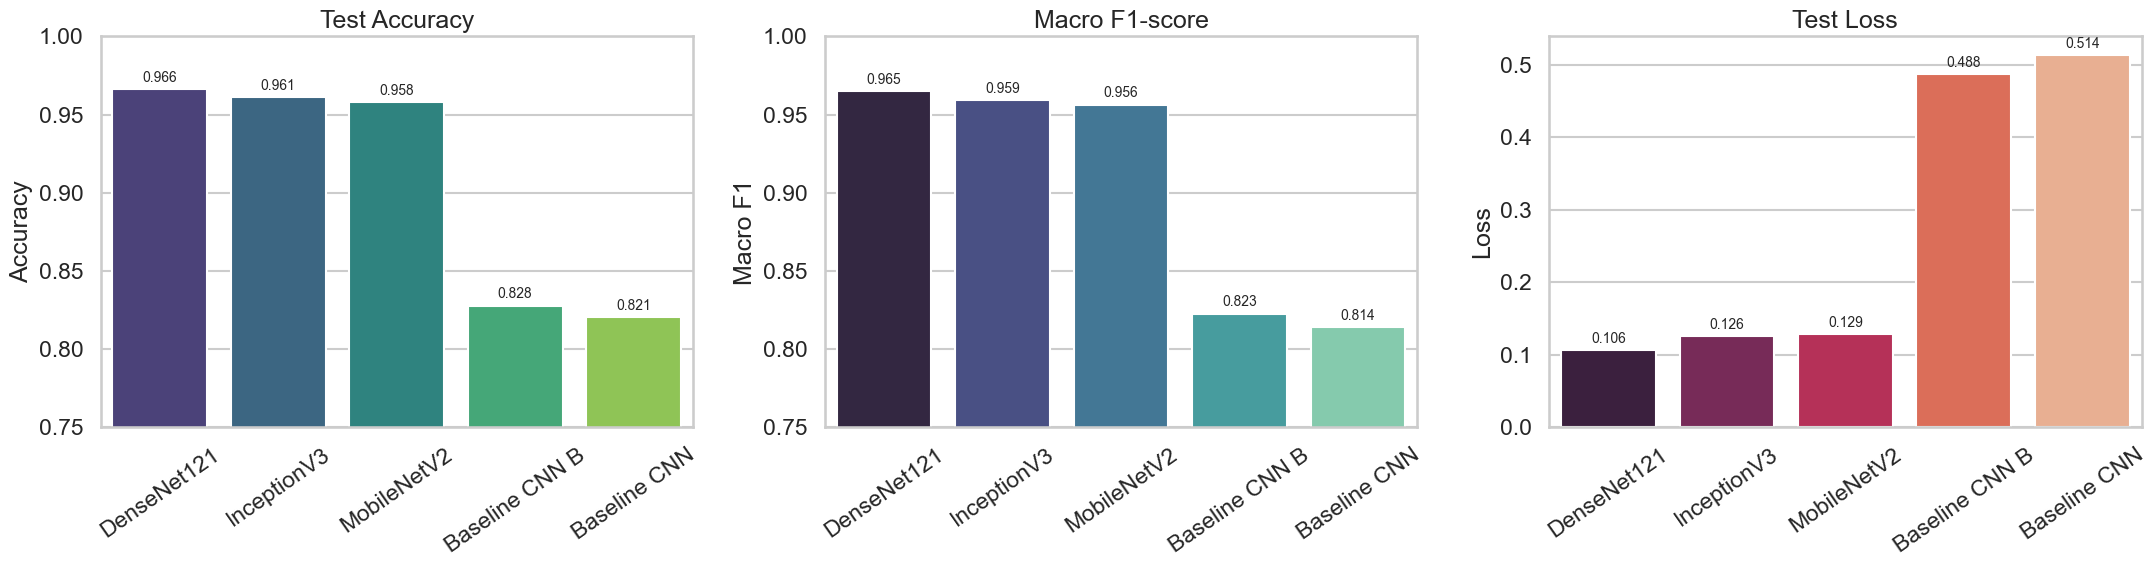

In [4]:
plot_df = metrics_df.copy()
model_order = plot_df.sort_values("test_accuracy", ascending=False)["model"]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=plot_df, x="model", y="test_accuracy", order=model_order, hue="model", legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Test Accuracy")
axes[0].set_ylim(0.75, 1.00)
axes[0].set_xlabel("")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=35)
annotate_bars(axes[0], plot_df.set_index("model").loc[model_order, "test_accuracy"], fmt="{:.3f}")

sns.barplot(data=plot_df, x="model", y="macro_f1", order=model_order, hue="model", legend=False, ax=axes[1], palette="mako")
axes[1].set_title("Macro F1-score")
axes[1].set_ylim(0.75, 1.00)
axes[1].set_xlabel("")
axes[1].set_ylabel("Macro F1")
axes[1].tick_params(axis="x", rotation=35)
annotate_bars(axes[1], plot_df.set_index("model").loc[model_order, "macro_f1"], fmt="{:.3f}")

sns.barplot(data=plot_df, x="model", y="test_loss", order=model_order, hue="model", legend=False, ax=axes[2], palette="rocket")
axes[2].set_title("Test Loss")
axes[2].set_xlabel("")
axes[2].set_ylabel("Loss")
axes[2].tick_params(axis="x", rotation=35)
annotate_bars(axes[2], plot_df.set_index("model").loc[model_order, "test_loss"], fmt="{:.3f}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_accuracy_f1_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Genel Sonuç Yorumu

Genel sonuçlara göre en başarılı model **DenseNet121** olmuştur. DenseNet121 test kümesinde **0.9662 accuracy**, **0.9650 macro F1-score**, **0.9662 weighted F1-score** ve **0.1065 test loss** değerine ulaşmıştır.

İkinci sırada **InceptionV3** yer almaktadır. InceptionV3 test accuracy değeri **0.9610**, macro F1-score değeri ise **0.9594** olarak hesaplanmıştır. Üçüncü transfer learning modeli olan **MobileNetV2** de **0.9578 test accuracy** ve **0.9563 macro F1-score** ile baseline modellerin oldukça üzerinde performans vermiştir.

Baseline CNN modeli **0.8207 test accuracy** değerinde kalırken, augmentation kullanılan Baseline CNN B modeli **0.8279 test accuracy** değerine ulaşmıştır. Bu iki model arasındaki fark sınırlıdır. Buna karşılık transfer learning modelleri yaklaşık **%95-97** accuracy aralığına çıkmıştır. Bu durum hazır ImageNet ağırlıklarının EuroSAT veri seti için güçlü bir özellik çıkarıcı olduğunu göstermektedir.

## 7. Baseline Modellerine Göre İyileşme

Bu bölümde her modelin ana baseline CNN modeline göre ne kadar iyileşme sağladığı hesaplanmıştır. Farklar yüzde puan cinsinden yorumlanmıştır.

In [5]:
baseline_row = metrics_df.loc[metrics_df["model"] == "Baseline CNN"].iloc[0]

improvement_df = metrics_df.copy()
improvement_df["accuracy_gain_vs_baseline"] = improvement_df["test_accuracy"] - baseline_row["test_accuracy"]
improvement_df["macro_f1_gain_vs_baseline"] = improvement_df["macro_f1"] - baseline_row["macro_f1"]
improvement_df["loss_reduction_vs_baseline"] = baseline_row["test_loss"] - improvement_df["test_loss"]

improvement_display = improvement_df[[
    "model",
    "test_accuracy",
    "accuracy_gain_vs_baseline",
    "macro_f1",
    "macro_f1_gain_vs_baseline",
    "test_loss",
    "loss_reduction_vs_baseline",
]].copy()

for column in ["accuracy_gain_vs_baseline", "macro_f1_gain_vs_baseline", "loss_reduction_vs_baseline"]:
    improvement_display[column] = improvement_display[column].round(4)

display(improvement_display)

,model,test_accuracy,accuracy_gain_vs_baseline,macro_f1,macro_f1_gain_vs_baseline,test_loss,loss_reduction_vs_baseline
0,DenseNet121,0.966173,0.1454,0.964951,0.1511,0.106461,0.4071
1,InceptionV3,0.960988,0.1402,0.959422,0.1455,0.125979,0.3876
2,MobileNetV2,0.957778,0.1370,0.956325,0.1424,0.128608,0.3849
3,Baseline CNN B,0.827901,0.0072,0.822755,0.0089,0.487719,0.0258
4,Baseline CNN,0.820741,0.0000,0.813885,0.0000,0.513538,0.0000


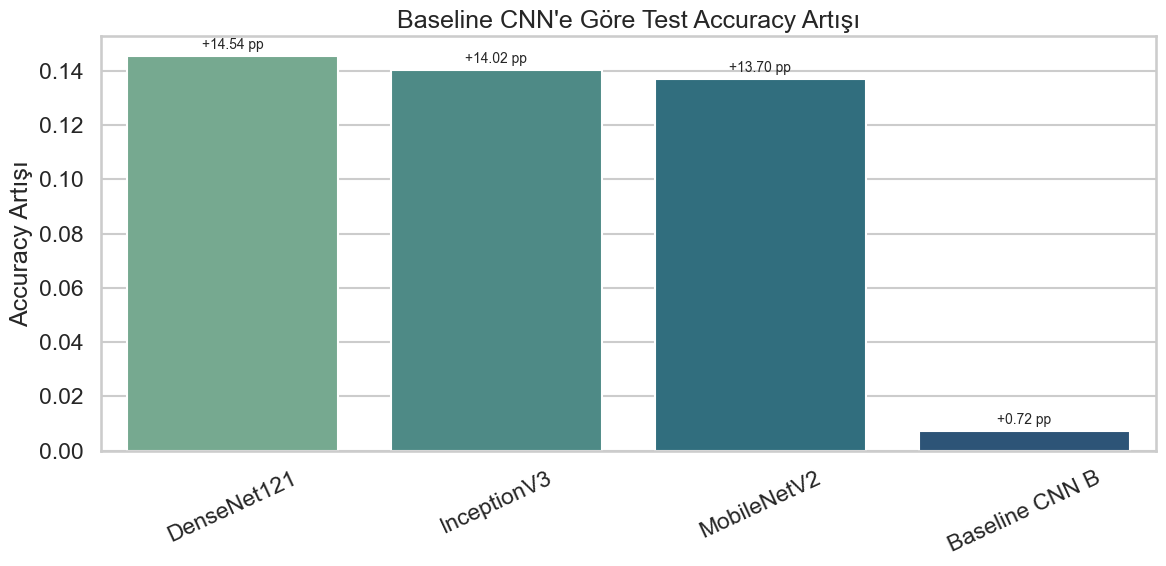

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
bar_df = improvement_df[improvement_df["model"] != "Baseline CNN"].sort_values("accuracy_gain_vs_baseline", ascending=False)
sns.barplot(data=bar_df, x="model", y="accuracy_gain_vs_baseline", hue="model", legend=False, palette="crest", ax=ax)
ax.set_title("Baseline CNN'e Göre Test Accuracy Artışı")
ax.set_xlabel("")
ax.set_ylabel("Accuracy Artışı")
ax.tick_params(axis="x", rotation=25)
annotate_bars(ax, bar_df["accuracy_gain_vs_baseline"] * 100, fmt="+{:.2f}", suffix=" pp")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "accuracy_gain_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Baseline Karşılaştırması Yorumu

Baseline CNN B modeli, ana baseline CNN modeline göre yaklaşık **0.72 yüzde puan** accuracy artışı sağlamıştır. Bu sonuç augmentation kullanımının sade CNN üzerinde küçük bir genelleme katkısı verdiğini göstermektedir.

Transfer learning modellerindeki artış çok daha belirgindir. MobileNetV2 baseline CNN'e göre yaklaşık **13.70 yüzde puan**, DenseNet121 yaklaşık **14.54 yüzde puan**, InceptionV3 ise yaklaşık **14.02 yüzde puan** accuracy artışı sağlamıştır.

Bu fark, projenin ana konusu olan transfer learning yaklaşımının deneysel olarak desteklendiğini göstermektedir. Hazır ağırlıklı modeller, sıfırdan eğitilen sade CNN'e göre çok daha güçlü özellik temsilleri üretmiştir.

## 9. Feature Extraction ve Fine-tuning Etkisi

Transfer learning modellerinde iki aşamalı eğitim yapılmıştır. İlk aşamada model tabanı dondurulmuş, yalnızca son sınıflandırıcı katmanlar eğitilmiştir. İkinci aşamada ise model tabanının son katmanlarından bir kısmı düşük learning rate ile eğitime açılmıştır.

Bu bölümde fine-tuning sonrasında validation accuracy değerinin ne kadar değiştiği incelenmiştir.

,model,best_feature_val_accuracy,best_finetune_val_accuracy,fine_tuning_gain,feature_epochs_ran,fine_tune_epochs_ran
1,InceptionV3,0.920741,0.956543,0.035802,15.0,10.0
2,MobileNetV2,0.931358,0.954321,0.022963,14.0,10.0
0,DenseNet121,0.942716,0.958519,0.015802,14.0,10.0


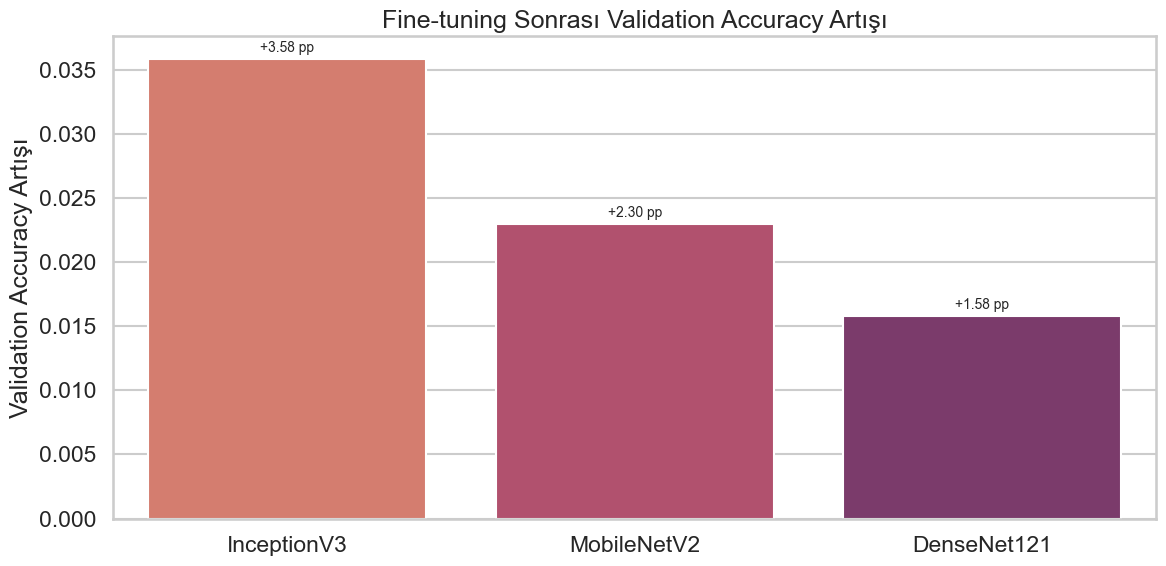

In [7]:
transfer_models = metrics_df[metrics_df["model"].isin(["MobileNetV2", "DenseNet121", "InceptionV3"])].copy()
transfer_models["fine_tuning_gain"] = transfer_models["best_finetune_val_accuracy"] - transfer_models["best_feature_val_accuracy"]

fine_tuning_df = transfer_models[[
    "model",
    "best_feature_val_accuracy",
    "best_finetune_val_accuracy",
    "fine_tuning_gain",
    "feature_epochs_ran",
    "fine_tune_epochs_ran",
]].sort_values("fine_tuning_gain", ascending=False)

display(fine_tuning_df)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=fine_tuning_df, x="model", y="fine_tuning_gain", hue="model", legend=False, palette="flare", ax=ax)
ax.set_title("Fine-tuning Sonrası Validation Accuracy Artışı")
ax.set_xlabel("")
ax.set_ylabel("Validation Accuracy Artışı")
annotate_bars(ax, fine_tuning_df["fine_tuning_gain"] * 100, fmt="+{:.2f}", suffix=" pp")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fine_tuning_validation_gain.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Fine-tuning Yorumu

Fine-tuning etkisi üç transfer learning modelinde de pozitiftir. En yüksek validation accuracy artışı **InceptionV3** modelinde görülmüştür. InceptionV3 feature extraction aşamasında **0.9207** validation accuracy değerine ulaşırken, fine-tuning sonrasında bu değer **0.9565** seviyesine çıkmıştır. Bu yaklaşık **3.58 yüzde puanlık** bir artıştır.

MobileNetV2 modelinde validation accuracy **0.9314** seviyesinden **0.9543** seviyesine yükselmiştir. Bu yaklaşık **2.30 yüzde puanlık** bir artıştır. DenseNet121 modelinde ise değer **0.9427** seviyesinden **0.9585** seviyesine çıkmıştır. Bu yaklaşık **1.58 yüzde puanlık** bir artıştır.

Bu sonuçlar fine-tuning aşamasının gereksiz olmadığını göstermektedir. Ancak artış miktarı modele göre değişmiştir. DenseNet121 feature extraction aşamasında zaten güçlü başladığı için fine-tuning kazancı daha sınırlı kalmıştır. InceptionV3 ise feature extraction aşamasında daha düşük başladığı için fine-tuning adımından daha fazla fayda görmüştür.

## 11. Sınıf Bazlı F1-score Karşılaştırması

Genel accuracy yüksek olsa bile bazı sınıflarda performans düşük olabilir. Bu nedenle her modelin sınıf bazlı F1-score değerleri karşılaştırılmıştır. F1-score, precision ve recall değerlerini birlikte değerlendirdiği için sınıf bazlı performans yorumunda önemli bir metriktir.

In [8]:
report_files = {
    "Baseline CNN": "baseline_cnn_classification_report.csv",
    "Baseline CNN B": "baseline_cnn_b_classification_report.csv",
    "MobileNetV2": "mobilenetv2_classification_report.csv",
    "DenseNet121": "densenet121_classification_report.csv",
    "InceptionV3": "inceptionv3_classification_report.csv",
}

class_records = []

for model_name, file_name in report_files.items():
    report_df = pd.read_csv(REPORTS_DIR / file_name, index_col=0)
    class_rows = report_df.loc[[idx for idx in report_df.index if idx not in ["accuracy", "macro avg", "weighted avg"]]].copy()
    class_rows["model"] = model_name
    class_rows["class"] = class_rows.index
    class_records.append(class_rows.reset_index(drop=True))

class_metrics_df = pd.concat(class_records, ignore_index=True)
class_metrics_df.to_csv(REPORTS_DIR / "class_f1_comparison.csv", index=False, encoding="utf-8-sig")

f1_pivot = class_metrics_df.pivot(index="model", columns="class", values="f1-score")
f1_pivot = f1_pivot.loc[["Baseline CNN", "Baseline CNN B", "MobileNetV2", "DenseNet121", "InceptionV3"]]

display(f1_pivot.round(4))

class,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
model,,,,,,,,,,
Baseline CNN,0.8588,0.8975,0.7948,0.5989,0.9062,0.8185,0.7255,0.8862,0.7367,0.9157
Baseline CNN B,0.8504,0.8927,0.8141,0.6686,0.9031,0.8288,0.7066,0.9047,0.7681,0.8905
MobileNetV2,0.9425,0.9777,0.9408,0.9467,0.9789,0.9278,0.9342,0.9843,0.9437,0.9865
DenseNet121,0.9643,0.9834,0.9625,0.9436,0.9815,0.9549,0.9451,0.9832,0.9432,0.9877
InceptionV3,0.9495,0.9834,0.9456,0.9531,0.9786,0.9249,0.9407,0.9811,0.9485,0.9888


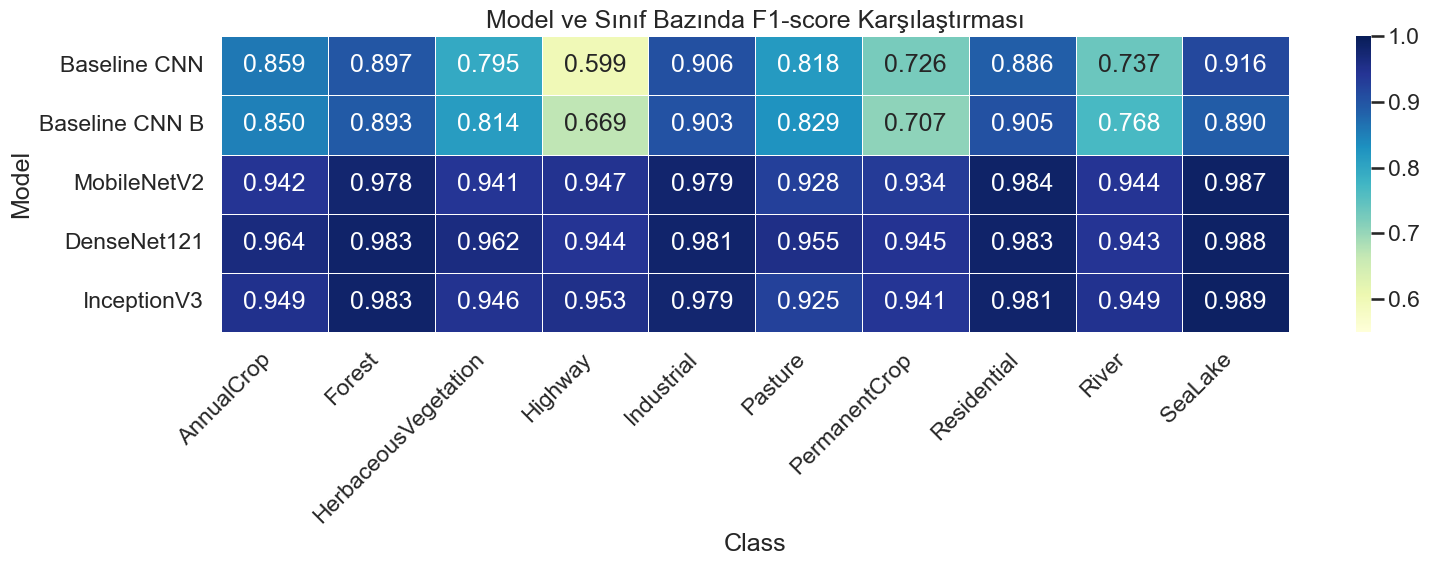

In [9]:
plt.figure(figsize=(16, 6))
sns.heatmap(
    f1_pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.55,
    vmax=1.00,
    linewidths=0.5,
)
plt.title("Model ve Sınıf Bazında F1-score Karşılaştırması")
plt.xlabel("Class")
plt.ylabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
summary_class_rows = []

for model_name, group in class_metrics_df.groupby("model"):
    best = group.sort_values("f1-score", ascending=False).head(3)
    worst = group.sort_values("f1-score", ascending=True).head(3)
    summary_class_rows.append({
        "model": model_name,
        "best_classes_by_f1": ", ".join(f"{row['class']} ({row['f1-score']:.3f})" for _, row in best.iterrows()),
        "weakest_classes_by_f1": ", ".join(f"{row['class']} ({row['f1-score']:.3f})" for _, row in worst.iterrows()),
    })

class_summary_df = pd.DataFrame(summary_class_rows)
class_summary_df = class_summary_df.set_index("model").loc[["Baseline CNN", "Baseline CNN B", "MobileNetV2", "DenseNet121", "InceptionV3"]].reset_index()
display(class_summary_df)

,model,best_classes_by_f1,weakest_classes_by_f1
0,Baseline CNN,"SeaLake (0.916), Industrial (0.906), Forest (0...","Highway (0.599), PermanentCrop (0.726), River ..."
1,Baseline CNN B,"Residential (0.905), Industrial (0.903), Fores...","Highway (0.669), PermanentCrop (0.707), River ..."
2,MobileNetV2,"SeaLake (0.987), Residential (0.984), Industri...","Pasture (0.928), PermanentCrop (0.934), Herbac..."
3,DenseNet121,"SeaLake (0.988), Forest (0.983), Residential (...","River (0.943), Highway (0.944), PermanentCrop ..."
4,InceptionV3,"SeaLake (0.989), Forest (0.983), Residential (...","Pasture (0.925), PermanentCrop (0.941), Herbac..."


## 12. Sınıf Bazlı Sonuçların Yorumu

Sınıf bazlı F1-score değerleri, transfer learning modellerinin sadece genel accuracy açısından değil, sınıf bazında da güçlü olduğunu göstermektedir.

Baseline CNN modelinde en zayıf sınıf **Highway** olmuştur. Highway F1-score değeri ana baseline modelde **0.5989** seviyesindedir. Bu değer, modelin yol görüntülerini başka sınıflarla sık karıştırdığını göstermektedir. Baseline CNN B modelinde Highway F1-score değeri **0.6686** seviyesine yükselmiştir; augmentation burada bir miktar katkı sağlamıştır.

Transfer learning modellerinde en düşük F1-score değerleri bile oldukça yüksektir. MobileNetV2 modelinde en düşük F1-score **Pasture (0.9278)**, DenseNet121 modelinde **River (0.9432)**, InceptionV3 modelinde ise **Pasture (0.9249)** sınıfındadır. Bu durum transfer learning modellerinin zor sınıflarda bile baseline modellere göre çok daha dengeli sonuç verdiğini göstermektedir.

Genel olarak **SeaLake**, **Forest**, **Residential** ve **Industrial** sınıfları tüm güçlü modellerde yüksek F1-score değerleriyle ayrılmıştır. Tarım ve bitki örtüsü sınıfları ise görsel benzerlik nedeniyle görece daha zorlayıcı kalmıştır.

## 13. Model Karmaşıklığı, Parametre Sayısı ve Eğitim Süresi

Model seçimi yalnızca accuracy değerine göre yapılmamalıdır. Daha büyük modeller genellikle daha yüksek başarı sağlayabilir, ancak daha fazla bellek ve eğitim süresi gerektirir. Bu nedenle parametre sayısı ve eğitim süresi de değerlendirilmiştir.

In [11]:
complexity_df = metrics_df[[
    "model",
    "test_accuracy",
    "macro_f1",
    "total_params",
    "total_params_million",
    "trainable_params_after_finetuning",
    "training_time_minutes",
]].copy()

complexity_df["trainable_params_after_finetuning_million"] = complexity_df["trainable_params_after_finetuning"] / 1_000_000
complexity_df = complexity_df.sort_values("test_accuracy", ascending=False)

display(complexity_df)

,model,test_accuracy,macro_f1,total_params,total_params_million,trainable_params_after_finetuning,training_time_minutes,trainable_params_after_finetuning_million
0,DenseNet121,0.966173,0.964951,7047754,7.047754,1071114.0,52.398058,1.071114
1,InceptionV3,0.960988,0.959422,21823274,21.823274,10555402.0,39.283905,10.555402
2,MobileNetV2,0.957778,0.956325,2270794,2.270794,1523530.0,22.651518,1.523530
3,Baseline CNN B,0.827901,0.822755,111050,0.111050,NaN,11.930146,NaN
4,Baseline CNN,0.820741,0.813885,111050,0.111050,NaN,11.437312,NaN


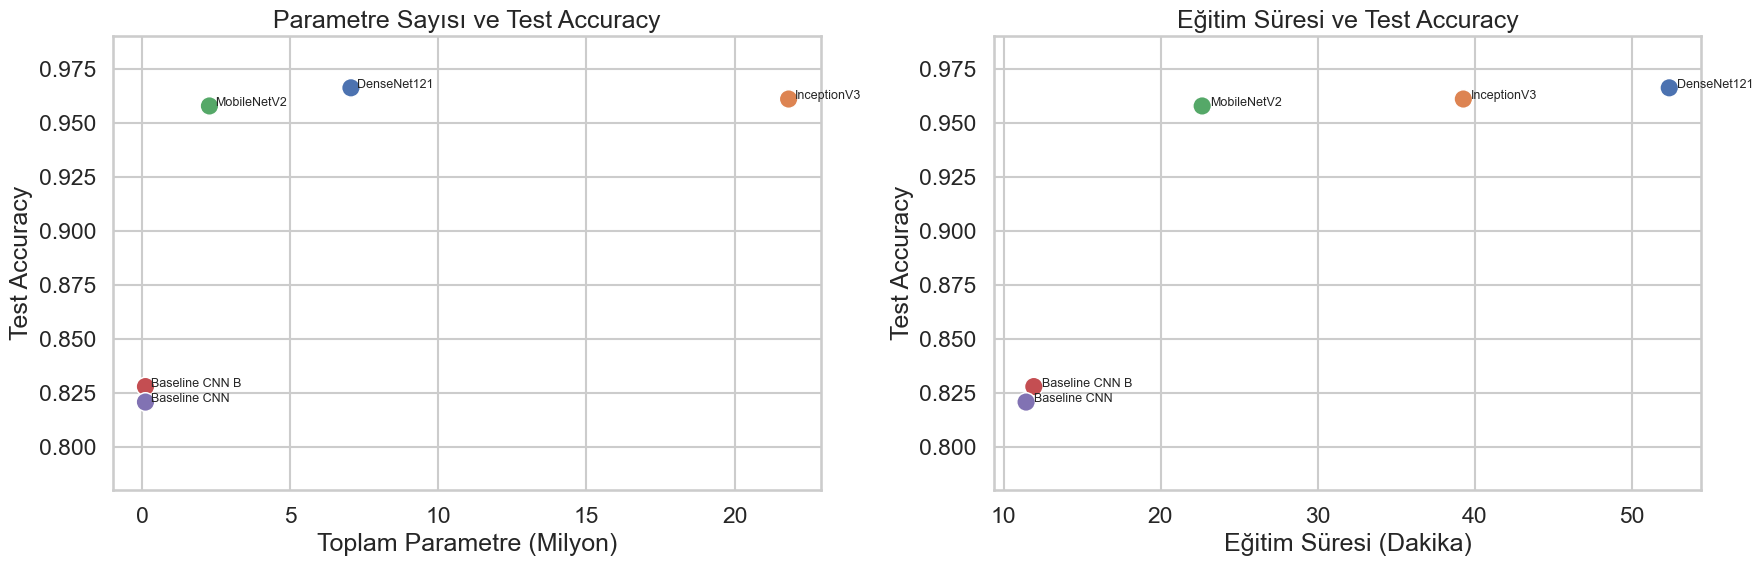

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(
    data=complexity_df,
    x="total_params_million",
    y="test_accuracy",
    hue="model",
    s=180,
    ax=axes[0],
)
for _, row in complexity_df.iterrows():
    axes[0].text(row["total_params_million"] + 0.2, row["test_accuracy"], row["model"], fontsize=9)
axes[0].set_title("Parametre Sayısı ve Test Accuracy")
axes[0].set_xlabel("Toplam Parametre (Milyon)")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_ylim(0.78, 0.99)
axes[0].legend([], [], frameon=False)

sns.scatterplot(
    data=complexity_df,
    x="training_time_minutes",
    y="test_accuracy",
    hue="model",
    s=180,
    ax=axes[1],
)
for _, row in complexity_df.iterrows():
    axes[1].text(row["training_time_minutes"] + 0.5, row["test_accuracy"], row["model"], fontsize=9)
axes[1].set_title("Eğitim Süresi ve Test Accuracy")
axes[1].set_xlabel("Eğitim Süresi (Dakika)")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0.78, 0.99)
axes[1].legend([], [], frameon=False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_complexity_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Karmaşıklık Yorumu

Model karmaşıklığı açısından önemli farklar vardır. Baseline CNN modelleri yalnızca **111.050** parametreye sahiptir. Bu modeller hafiftir; ancak test accuracy değerleri yaklaşık **0.82** seviyesinde kalmıştır.

MobileNetV2 **2.270.794** parametre ile transfer learning modelleri arasında en küçük modeldir. Buna rağmen **0.9578** test accuracy değerine ulaşmıştır. Bu nedenle hesaplama maliyeti ve başarı dengesi açısından güçlü bir modeldir.

DenseNet121 **7.047.754** parametreye sahiptir ve **0.9662** test accuracy ile en iyi sonucu vermiştir. InceptionV3 ise **21.823.274** parametre ile en büyük modeldir; ancak test accuracy değeri **0.9610** ile DenseNet121'in biraz gerisinde kalmıştır.

Bu sonuçlara göre en yüksek başarı hedefleniyorsa DenseNet121 daha uygun görünmektedir. Daha hafif ve hızlı bir model istenirse MobileNetV2 iyi bir alternatif olabilir. InceptionV3 güçlü bir model olsa da bu deneyde daha yüksek parametre sayısına rağmen DenseNet121'i geçememiştir.

## 15. Final Model Seçimi

Bu projede final model adayı **DenseNet121** olarak seçilmiştir.

Bu seçimin gerekçeleri:

1. En yüksek test accuracy değerini vermiştir: **0.9662**
2. En yüksek macro F1-score değerine ulaşmıştır: **0.9650**
3. En düşük test loss değerini üretmiştir: **0.1065**
4. Tüm sınıflarda F1-score değerleri 0.94 üzerinde kalmıştır
5. InceptionV3'e göre daha az parametreyle daha iyi sonuç vermiştir

MobileNetV2, daha düşük parametre sayısı ve daha kısa eğitim süresi nedeniyle pratik kullanımda güçlü bir alternatiftir. Ancak akademik değerlendirmede genel başarı, sınıf dengesi ve loss değeri birlikte ele alındığında DenseNet121 daha iyi final model olarak öne çıkmaktadır.

In [13]:
final_summary = {
    "selected_model": "DenseNet121",
    "reason": "Highest test accuracy, highest macro F1-score, lowest test loss, and strong class-level performance.",
    "test_accuracy": float(metrics_df.loc[metrics_df["model"] == "DenseNet121", "test_accuracy"].iloc[0]),
    "macro_f1": float(metrics_df.loc[metrics_df["model"] == "DenseNet121", "macro_f1"].iloc[0]),
    "weighted_f1": float(metrics_df.loc[metrics_df["model"] == "DenseNet121", "weighted_f1"].iloc[0]),
    "test_loss": float(metrics_df.loc[metrics_df["model"] == "DenseNet121", "test_loss"].iloc[0]),
    "main_baseline_accuracy": float(metrics_df.loc[metrics_df["model"] == "Baseline CNN", "test_accuracy"].iloc[0]),
    "accuracy_gain_vs_baseline": float(
        metrics_df.loc[metrics_df["model"] == "DenseNet121", "test_accuracy"].iloc[0]
        - metrics_df.loc[metrics_df["model"] == "Baseline CNN", "test_accuracy"].iloc[0]
    ),
}

summary_path = REPORTS_DIR / "final_model_recommendation.json"
summary_path.write_text(json.dumps(final_summary, indent=2, ensure_ascii=False), encoding="utf-8")

pd.DataFrame([final_summary])

,selected_model,reason,test_accuracy,macro_f1,weighted_f1,test_loss,main_baseline_accuracy,accuracy_gain_vs_baseline
0,DenseNet121,"Highest test accuracy, highest macro F1-score,...",0.966173,0.964951,0.96618,0.106461,0.820741,0.145432


## 16. Rapor İçin Kullanılabilecek Sonuç Cümleleri

Bu deneylerde transfer learning modelleri, sıfırdan eğitilen baseline CNN modellerine göre belirgin bir performans artışı sağlamıştır. Baseline CNN modeli test kümesinde 0.8207 accuracy değerine ulaşırken, transfer learning modelleri 0.9578 ile 0.9662 arasında accuracy değerleri üretmiştir.

En iyi sonuç DenseNet121 modeli ile elde edilmiştir. DenseNet121 test kümesinde 0.9662 accuracy, 0.9650 macro F1-score ve 0.1065 test loss değerine ulaşmıştır. Bu sonuçlar, DenseNet121'in EuroSAT RGB veri setinde hem genel doğruluk hem de sınıf bazlı denge açısından en başarılı model olduğunu göstermektedir.

Fine-tuning aşaması tüm transfer learning modellerinde validation accuracy değerini artırmıştır. Bu durum, önceden eğitilmiş ImageNet ağırlıklarının yalnızca doğrudan kullanılmasının değil, son katmanların veri setine kontrollü şekilde uyarlanmasının da faydalı olduğunu göstermektedir.

Sınıf bazlı analizde SeaLake, Forest, Residential ve Industrial sınıfları genel olarak daha yüksek F1-score değerleriyle ayrılmıştır. Pasture, PermanentCrop, River ve Highway gibi sınıflar ise bazı modellerde görece daha zorlayıcı kalmıştır. Bu durum küçük uydu kesitlerinde tarımsal alan, bitki örtüsü, yol ve nehir dokularının bazı örneklerde birbirine görsel olarak yaklaşabilmesiyle açıklanabilir.

## 17. Sınırlılıklar ve Değerlendirme Notları

Bu çalışmada tüm modeller aynı sabit split üzerinde değerlendirilmiştir. Bu yaklaşım model karşılaştırmasını adil hale getirir; ancak farklı random seed değerleriyle ek tekrarlar yapılmadığı için sonuçlar tek split üzerindeki performansı temsil eder.

EuroSAT RGB veri seti 64x64 çözünürlüklü küçük uydu görüntülerinden oluşmaktadır. Görüntüler model girişinde 224x224 boyutuna ölçeklenmiştir. Bu işlem transfer learning modelleriyle uyum sağlar; ancak ham görüntüde olmayan yeni ayrıntı üretmez.

Sonuçlar accuracy, loss, macro F1-score, weighted F1-score ve confusion matrix üzerinden değerlendirilmiştir. Daha ileri bir çalışma için farklı seed değerleriyle tekrar deneyleri, farklı fine-tuning derinlikleri veya renk tabanlı augmentation stratejileri ayrıca incelenebilir.